In [30]:

import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px

In [31]:
df = pd.read_csv("../data/papers.csv")
total_papers = len(df)
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Link to Data', 'Data Details', 'Size',
       'Number of Prompts', 'Medical Application', 'Task Type', 'Topic',
       'Note', 'Bias Evaluation Metric', 'Bias Definition', 'Conclusions',
       'Race / Ethnic Bias', 'Language Bias', 'Age Bias', 'Gender Bias',
       'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Geography / Cultural Bias', 'Evaluated LLMs',
       'Reference Standard \n(Human / Model / System / Physician)',
       'Patient Inclusion\n(Yes / No)', 'Has Debiasing',
       'Debias - Focus\n(Data/Train/Inference)', 'Debias-details'],
      dtype='str')

In [32]:
availabilities_lst = df["Data Availability"].tolist()

availability_freqs = defaultdict(int)

for a in availabilities_lst:  

    if isinstance(a, float):
        availability_freqs[str(a)] += 1
        continue

    s = a.strip().lower()
    
    availabilities = [av.strip() for av in s.split(',')]
    
    for availability in availabilities:
        availability_freqs[availability] += 1



In [ ]:
# del availability_freqs["linked at the bottom of the paper: specific details such as the survey questions (appendix 1) and median scores for individual components"]

from typing import Any


availability_freqs["regulated"] += 1
# del availability_freqs["regulated data"]

del availability_freqs["nan"]
del availability_freqs["outdated"]
del availability_freqs["unclear"]
del availability_freqs["will need help"]
del availability_freqs["needs a deeper dive"]
del availability_freqs["yes"]

availability_freqs["couldn't find"] += 1
# del availability_freqs["couldn't found"]


availability_freqs = dict[Any, int](sorted(availability_freqs.items(), key=lambda kv: kv[1]))
availability_freqs = dict(reversed(list(availability_freqs.items())))


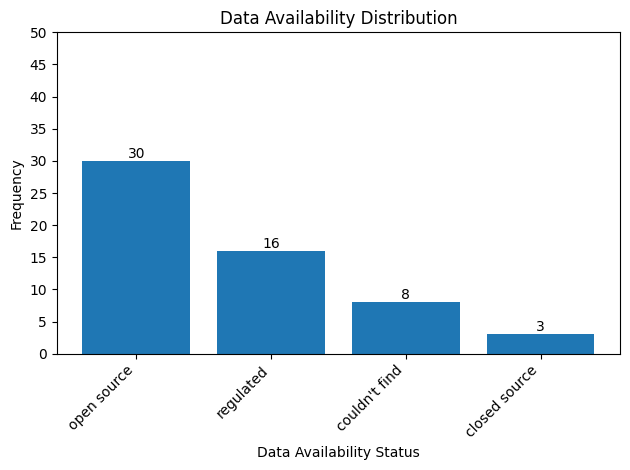

In [34]:
plt.figure()

languages = list(availability_freqs.keys())
counts = list(availability_freqs.values())

bars = plt.bar(languages, counts)

for i, count in enumerate(counts):
    percent = (count / total_papers) * 100
    plt.text(i, count, f"{count}",
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Data Availability Status")
plt.ylabel("Frequency")
plt.ylim((0, 50))
plt.yticks(range(0, 51, 5))
plt.title("Data Availability Distribution")
plt.tight_layout()
plt.show()